# 02 — Full Echo pipeline

Demonstrate `Echo.train` / `Echo.test` end-to-end on a 3-variable problem:

- Generate train and test from the same distribution → check that p-values are uniform on (0, 1).
- Generate a *drifted* test → check that the p-value distribution departs from U(0, 1) and that the excess accumulates in the low-p tail (physics convention: small p = anomalous).
- Compare the whitened variables `z0, z1, z2` between train and test to localize where the discrepancy sits.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kstest, norm

from echo import Echo
from echo.synthetic import make_sample


## 1. Generate train and a few test samples

Three variables: `x` (normal), `y` (uniform), `z` (normal). Latent correlation 0.5.

In [2]:
dists   = ['normal', 'uniform', 'normal']
params  = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
rho     = 0.5

train     = make_sample(30_000, dists, parameters=params, correlation=rho, seed=1)
test_h0   = make_sample(10_000, dists, parameters=params, correlation=rho, seed=2)

# Drift case 1: mean shift on x.
test_drift_mean      = make_sample(10_000, dists, parameters=params, correlation=rho, seed=3)
test_drift_mean['x'] = test_drift_mean['x'] + 0.5

# Drift case 2: width change on z.
test_drift_width      = make_sample(10_000, dists, parameters=params, correlation=rho, seed=4)
test_drift_width['z'] = test_drift_width['z'] * 1.3

print('train     :', train.shape)
print('test_h0   :', test_h0.shape)
print('drift mean:', test_drift_mean.shape)
print('drift wide:', test_drift_width.shape)


train     : (30000, 3)
test_h0   : (10000, 3)
drift mean: (10000, 3)
drift wide: (10000, 3)


## 2. Train Echo on the train sample

After `train(...)`, the object stores everything needed to score any new sample: per-column ECDFs, rotation matrix, whitening scales, and the chi2 ECDF used for p-values.

In [3]:
echo = Echo()
z_train, p_train = echo.train(train)

print('eigenvalues (sorted desc):', echo._eigenvalues.round(3))
print('rotation matrix:')
print(np.round(echo._rotation, 3))
print()
print('z_train summary:')
print(pd.DataFrame({'mean': z_train.mean(), 'std': z_train.std()}).round(3))
print()
print('z_train correlation (should be ≈ I):')
print(z_train.corr().round(2))


eigenvalues (sorted desc): [1.987 0.51  0.501]
rotation matrix:
[[-0.579  0.262 -0.772]
 [-0.576 -0.802  0.159]
 [-0.578  0.537  0.615]]

z_train summary:
    mean  std
z0  -0.0  1.0
z1  -0.0  1.0
z2   0.0  1.0

z_train correlation (should be ≈ I):
     z0   z1   z2
z0  1.0 -0.0 -0.0
z1 -0.0  1.0  0.0
z2 -0.0  0.0  1.0


## 3. Apply to test samples

One call per scenario. Each returns `(z_df, p_series)`.

In [4]:
z_h0,    p_h0    = echo.test(test_h0)
z_drift, p_drift = echo.test(test_drift_mean)
z_wide,  p_wide  = echo.test(test_drift_width)

summary = pd.DataFrame({
    'sample':   ['train', 'test_h0', 'drift_mean', 'drift_width'],
    'mean(p)':  [p_train.mean(), p_h0.mean(), p_drift.mean(), p_wide.mean()],
    'frac(p<0.05)': [
        (p_train < 0.05).mean(),
        (p_h0    < 0.05).mean(),
        (p_drift < 0.05).mean(),
        (p_wide  < 0.05).mean(),
    ],
    'KS vs U(0,1)':  [
        kstest(p_train, 'uniform').statistic,
        kstest(p_h0,    'uniform').statistic,
        kstest(p_drift, 'uniform').statistic,
        kstest(p_wide,  'uniform').statistic,
    ],
})
summary.round(4)


,sample,mean(p),frac(p<0.05),"KS vs U(0,1)"
0,train,0.5000,0.0500,0.0000
1,test_h0,0.4962,0.0508,0.0103
2,drift_mean,0.4639,0.0736,0.0565
3,drift_width,0.4341,0.1068,0.1012


## 4. p-value histograms

Under H0 the histogram is flat; under drift the excess piles up at the low end (anomalies).

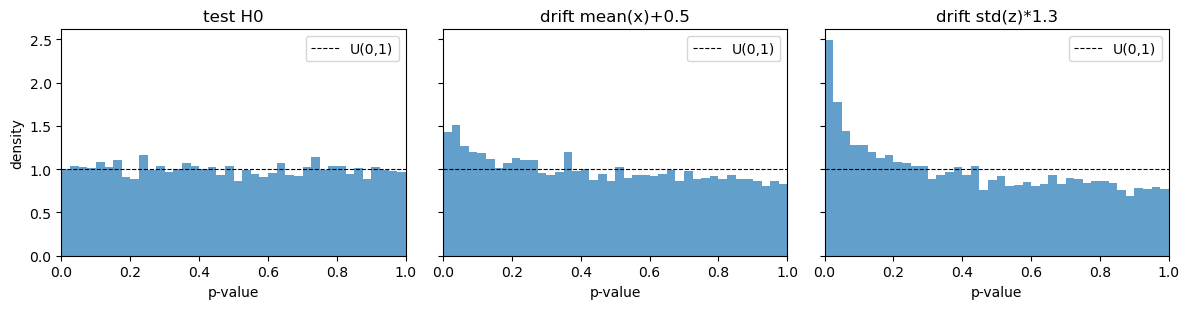

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, (title, p) in zip(
    axes,
    [('test H0', p_h0), ('drift mean(x)+0.5', p_drift), ('drift std(z)*1.3', p_wide)],
):
    ax.hist(p, bins=40, density=True, alpha=0.7)
    ax.axhline(1.0, color='k', lw=0.8, ls='--', label='U(0,1)')
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('p-value')
    ax.legend()
axes[0].set_ylabel('density')
fig.tight_layout()


## 5. Diagnostic: where is the discrepancy?

Under H0 each whitened variable `z_i` is N(0, 1) and independent across `i`. Comparing the marginals of `z` between train and a drifted test localizes which directions carry the discrepancy.

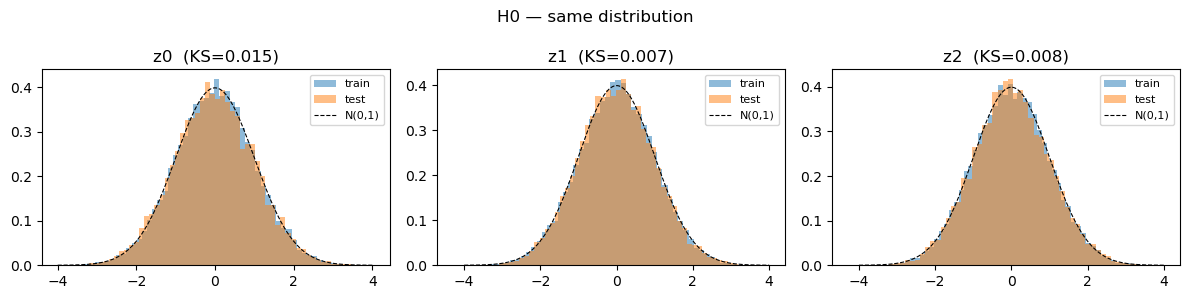

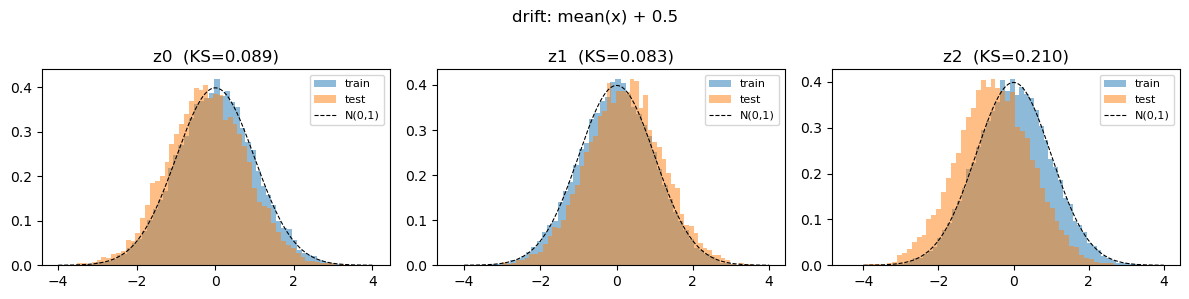

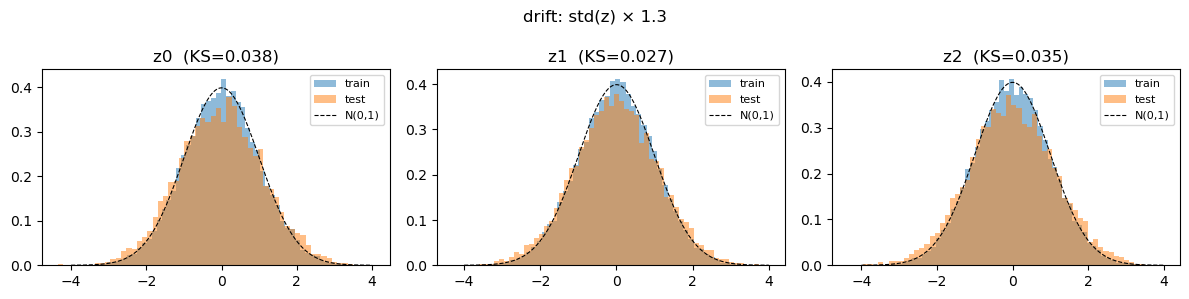

In [6]:
def plot_z_marginals(z_train, z_test, title):
    grid = np.linspace(-4, 4, 200)
    pdf  = norm.pdf(grid)

    fig, axes = plt.subplots(1, z_train.shape[1], figsize=(4 * z_train.shape[1], 3))
    fig.suptitle(title)
    for ax, col in zip(axes, z_train.columns):
        ax.hist(z_train[col], bins=60, alpha=0.5, density=True, label='train')
        ax.hist(z_test[col],  bins=60, alpha=0.5, density=True, label='test')
        ax.plot(grid, pdf, 'k--', lw=0.8, label='N(0,1)')
        stat, _ = kstest(z_test[col], 'norm')
        ax.set_title(f'{col}  (KS={stat:.3f})')
        ax.legend(fontsize=8)
    fig.tight_layout()

plot_z_marginals(z_train, z_h0,    'H0 — same distribution')
plot_z_marginals(z_train, z_drift, 'drift: mean(x) + 0.5')
plot_z_marginals(z_train, z_wide,  'drift: std(z) × 1.3')


## 6. Sensitivity vs drift strength

How small a shift can echo detect? Sweep the mean of `x` and plot the fraction of test events with `p < 0.05`.

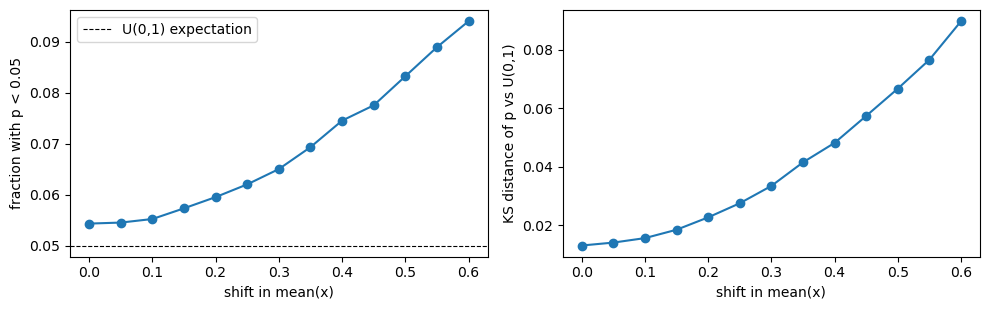

In [7]:
shifts        = np.linspace(0.0, 0.6, 13)
frac_low_p    = []
ks_vs_uniform = []

for delta in shifts:
    sample      = make_sample(10_000, dists, parameters=params, correlation=rho, seed=42)
    sample['x'] = sample['x'] + delta
    _, p_delta  = echo.test(sample)
    frac_low_p.append((p_delta < 0.05).mean())
    ks_vs_uniform.append(kstest(p_delta, 'uniform').statistic)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.plot(shifts, frac_low_p,    'o-')
ax1.axhline(0.05, color='k', ls='--', lw=0.8, label='U(0,1) expectation')
ax1.set_xlabel('shift in mean(x)')
ax1.set_ylabel('fraction with p < 0.05')
ax1.legend()

ax2.plot(shifts, ks_vs_uniform, 'o-')
ax2.set_xlabel('shift in mean(x)')
ax2.set_ylabel('KS distance of p vs U(0,1)')
fig.tight_layout()
